# Question 2: Three Methods for Option Pricing

In practice, derivatives are priced using a variety of techniques. In this section, we price the
same European call option using three different approaches—Black-Scholes (closed-form), Monte
Carlo simulation, and a binomial lattice—and compare them.

The chosen stock for the European call option is Eli Lilly and Company (LLY).

## 2.0 Setup

In [10]:
# Stock Ticker for Eli Lilly and Company (LLY)
ticker = "LLY"

# Stock price S0
# Most-current stock price (stock closed at $939.47 USD on April 10th, 2026)
stock_price = 939.47

# Risk-free rate r (annual % from FRED; decimal form for BS / MC formulas)
# Market Yield on U.S. Treasury Securities at 6-Month Constant Maturity (as of April 9th, 2026)
# https://fred.stlouisfed.org/series/DGS6MO
risk_free_rate_pct = 3.71
r = risk_free_rate_pct / 100.0

# At-the-money implied volatility σ from the Q1 volatility surface for LLY
implied_volatility = 0.2690

# At-the-money European call, 6 months to expiry (used in Problems 2.1–2.3)
time_to_expiry = 0.5  # years
strike_price = stock_price  # K = S0 (ATM)

# Monte Carlo (Problem 2.2): Euler–Maruyama time steps (Δt = T / n_steps)
mc_time_steps = 126
mc_seed = 42  # for reproducible simulations

## 2.1 Black-Scholes
(a) Compute the Black-Scholes price using the formula from Problem 1. This is your benchmark.

In [27]:
import numpy as np
from scipy.stats import norm


def bs_call(S, K, T, r, sigma):
    """
    Price the call option for stock S using the Black-Scholes European call
    formula from Question 1 (a)
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


# Define variables
S0 = stock_price  # Most-recent stock price
K = strike_price  # Strike price (K = S0 for an at-the-money call)
T = time_to_expiry  # Time to expiry (6 months as specified)
sigma = implied_volatility  # At-the-money implied volatility (from Question 1)

bs_benchmark_price = bs_call(S0, K, T, r, sigma)

print("Question 2.1    : Black-Scholes benchmark (European ATM call for LLY)")
print(f"LLY spot S0     : ${S0:,.2f}")
print(f"Strike K        : ${K:,.2f}  (ATM: K = S0)")
print(f"Time to expiry T: {T} years (6 months)")
print(f"Risk-free r     : {r:.4f} ({risk_free_rate_pct}% p.a.)")
print(f"Implied vol σ   : {sigma:.4f}")
print()
print(f"  Black-Scholes call price: ${bs_benchmark_price:,.4f}")

Question 2.1    : Black-Scholes benchmark (European ATM call for LLY)
LLY spot S0     : $939.47
Strike K        : $939.47  (ATM: K = S0)
Time to expiry T: 0.5 years (6 months)
Risk-free r     : 0.0371 (3.71% p.a.)
Implied vol σ   : 0.2690

  Black-Scholes call price: $79.4962


## 2.2 Monte Carlo

The fundamental pricing equation in derivatives says that the price of any contingent claim is the expected present value of its future cash flows under the risk-neutral measure. The problem is that this expectation is usually impossible to compute analytically—we don't have a closed-form expression for it. Monte Carlo sidesteps this by brute-forcing the expectation with a sample average: simulate $N$ independent draws of $S_T$, compute the payoff for each, average them, and discount. By the law of large numbers, the sample average converges to the true expectation as $N \to \infty$. The key ingredient is a model for how the stock price evolves.Under the risk-neutral measure, the stock price follows geometric Brownian motion:$$dS_t = r S_t \, dt + \sigma S_t \, dW_t$$This is a continuous-time stochastic differential equation (SDE). To simulate it on a computer, we need to discretize time. The Euler-Maruyama scheme approximates the SDE over a small time step $\Delta t$:$$S_{t+\Delta t} = S_t + r S_t \Delta t + \sigma S_t \sqrt{\Delta t} \, Z_t, \quad Z_t \sim \mathcal{N}(0,1)$$The $\sqrt{\Delta t}$ appears because Brownian motion increments scale as $\Delta W \sim \mathcal{N}(0, \Delta t)$, i.e., the standard deviation of a Brownian step over time $\Delta t$ is $\sqrt{\Delta t}$, not $\Delta t$. This square-root scaling is fundamental to stochastic calculus and is what distinguishes it from ordinary calculus.Simulate daily price paths using $n = 126$ time steps ($\Delta t = T/n$) to reach the terminal price $S_T$.The Monte Carlo price of a European call is then:$$\hat{C} = e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^{N} \max(S_T^{(i)} - K, 0)$$where $S_T^{(1)}, \dots, S_T^{(N)}$ are $N$ independent simulated terminal prices. The standard error of the estimate is:$$\text{SE} = \frac{\hat{\sigma}_{\text{payoff}}}{\sqrt{N}}, \quad \text{where } \hat{\sigma}_{\text{payoff}} = \text{std}\left( \left\{ e^{-rT} \max(S_T^{(i)} - K, 0) \right\}_{i=1}^N \right)$$This tells you how precisely you have estimated the price. A 95% confidence interval is $\hat{C} \pm 1.96 \cdot \text{SE}$.


### (a) Convergence Plot

Run the simulation for a range of path counts (e.g., N = 100 up to N = 500,000) and plot the MC price ± 2 standard errors against the BS price. At what N does the MC estimate stabilize to within 1% of the BS price? Report the MC price, standard error, and 95% confidence interval at each N. Does the MC price converge exactly to the BS price?

Monte Carlo (Euler-Maruyama, n = 126 steps)
  Simulated 500,000 terminal prices.

  Smallest N on this grid with relative error |MC - BS| / BS <= 1%: N = 384

  Monte Carlo (MC) price, Standard Error (SE), and 95% Confidence Interval (CI) at each N (grid):
     N  MC_price        SE  CI_95_low  CI_95_high  rel_err_vs_BS
   100 88.648196 14.351456  60.519343  116.777050       0.115125
   157 93.383884 11.315104  71.206280  115.561489       0.174697
   245 85.919246  8.350082  69.553086  102.285406       0.080797
   384 79.611578  6.380951  67.104914   92.118242       0.001452
   601 85.108417  5.287417  74.745079   95.471755       0.070598
   941 85.153983  4.116027  77.086570   93.221395       0.071171
  1473 81.938852  3.236076  75.596143   88.281561       0.030727
  2306 78.791125  2.522082  73.847845   83.734406       0.008869
  3610 79.723593  2.027896  75.748917   83.698269       0.002861
  5651 81.246727  1.642199  78.028017   84.465437       0.022021
  8848 81.154045  1.316367  

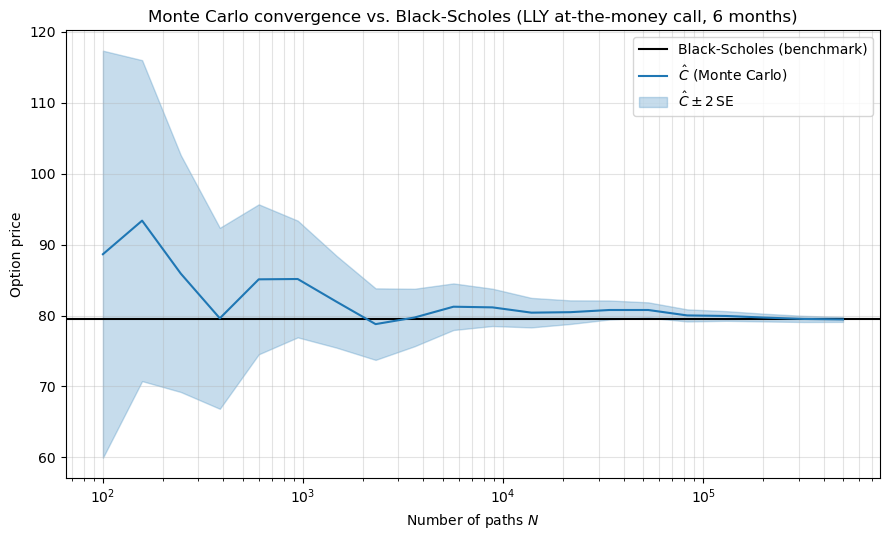

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt


def simulate_terminal_prices_gbm(S0, r, sigma, T, n_steps, n_paths, rng):
    """
    Run the simular for the stock price using Geometric Brownian Motion (gbm)
    """
    dt = T / n_steps  # The size of one time step
    sqrt_dt = np.sqrt(dt)
    S = np.full(
        n_paths, S0, dtype=np.float64
    )  # Array of "universes", all starting at S0
    for _ in range(n_steps):
        Z = rng.standard_normal(n_paths)  # Generate random shock

        # Update stock price using Euler-Maruyama
        S = (
            S + r * S * dt + sigma * S * sqrt_dt * Z
        )  # r is drift, sigma is volatility, Z is shock
    return S


rng = np.random.default_rng(mc_seed)  # Set the seed for reproducibility

N_max = 500_000
n_steps = mc_time_steps

t0 = time.perf_counter()
S_T = simulate_terminal_prices_gbm(S0, r, sigma, T, n_steps, N_max, rng)
t_sim = time.perf_counter() - t0

# Discounted payoffs
# If the stock price is above the strike price, the payoff is the difference
# between the stock price and the strike price (keep the profit)
# Otherwise, the option is worth $0
payoff = np.exp(-r * T) * np.maximum(S_T - K, 0.0)

# Path counts N is in the range [100, 500_000]
N_list = np.unique(
    np.clip(
        np.round(np.logspace(2, np.log10(N_max), 20)).astype(int),
        100,
        N_max,
    )
)
if N_list[0] < 100:
    N_list = np.unique(np.concatenate([[100], N_list]))
if N_list[-1] < N_max:
    N_list = np.unique(np.concatenate([N_list, [N_max]]))

rows = []
mc_prices = []
se_list = []

for N in N_list:
    # First N payoffs
    x = payoff[:N]
    # Monte Carlo price is the average of the payoffs
    c_hat = float(np.mean(x))
    # Standard error of average
    se = float(np.std(x, ddof=1) / np.sqrt(N)) if N > 1 else 0.0
    # 95% confidence interval
    ci_lo = c_hat - 1.96 * se
    ci_hi = c_hat + 1.96 * se
    rows.append(
        {
            "N": N,
            "MC_price": c_hat,
            "SE": se,
            "CI_95_low": ci_lo,
            "CI_95_high": ci_hi,
            # Relative error compared to Black-Scholes benchmark
            "rel_err_vs_BS": abs(c_hat - bs_benchmark_price) / bs_benchmark_price,
        }
    )
    mc_prices.append(c_hat)
    se_list.append(se)

mc_table = pd.DataFrame(rows)

# Smallest N on this grid within 1% of Black–Scholes (relative error on point estimate)
within_1pct = mc_table[mc_table["rel_err_vs_BS"] <= 0.01]
N_within_1pct = int(within_1pct["N"].iloc[0]) if len(within_1pct) else None

print("Monte Carlo (Euler-Maruyama, n = 126 steps)")
print(f"  Simulated {N_max:,} terminal prices.")
print()
if N_within_1pct is not None:
    print(
        f"  Smallest N on this grid with relative error |MC - BS| / BS <= 1%: N = {N_within_1pct:,}"
    )
else:
    print("  No N on this grid reaches |MC -  BS| / BS <= 1% (try larger N_max).")
print()
print(
    "  Monte Carlo (MC) price, Standard Error (SE), and 95% Confidence Interval (CI) at each N (grid):"
)
print(mc_table.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("  (rel_err_vs_BS = |MC_price - BS| / BS_benchmark_price)")
print()

# Create the convergence plot
fig, ax = plt.subplots(figsize=(9, 5.5))
# Black-Scholes benchmark (target)
ax.axhline(
    bs_benchmark_price,
    color="black",
    linestyle="-",
    linewidth=1.5,
    label="Black-Scholes (benchmark)",
)
mc_arr = np.array(mc_prices)
se_arr = np.array(se_list)
# Monte Carlo prices
ax.semilogx(N_list, mc_arr, color="C0", label=r"$\hat{C}$ (Monte Carlo)")
# Shaded area
ax.fill_between(
    N_list,
    mc_arr - 2 * se_arr,
    mc_arr + 2 * se_arr,
    color="C0",
    alpha=0.25,
    label=r"$\hat{C} \pm 2\,\mathrm{SE}$",
)
ax.set_xlabel("Number of paths $N$")
ax.set_ylabel("Option price")
ax.set_title(
    "Monte Carlo convergence vs. Black-Scholes (LLY at-the-money call, 6 months)"
)
ax.legend(loc="upper right")
ax.grid(True, which="both", alpha=0.35)
plt.tight_layout()
plt.show()

## 2.3 Binomial Lattice

The Cox-Ross-Rubinstein (CRR) binomial tree models the stock price as moving up or down at each discrete time step. Over $N$ steps of size $\Delta t = T/N$:

$$u = e^{\sigma\sqrt{\Delta t}}, \quad d = \frac{1}{u} = e^{-\sigma\sqrt{\Delta t}}, \quad q = \frac{e^{r \Delta t} - d}{u - d}

$$where $u$ and $d$ are the up and down factors, and $q$ is the risk-neutral probability of an up move. The tree is recombining: an up followed by a down gives the same price as a down followed by an up, so at time step $i$ there are only $i + 1$ distinct nodes rather than $2^i$. At node $(i, j)$—time step $i$ with $j$ up moves—the stock price is $S_0 u^j d^{(i-j)}$.

To price the option, you work backwards through the tree. The logic is as follows. At expiration, the option’s value is known—it is simply the payoff $\max(S_T - K, 0)$. Now step back one period. At any node one step before expiry, the stock will either go up or down next period, and in each case you know what the option will be worth (you just computed those terminal values). So the option at this node is equivalent to a one-period claim on those two known future values. Its fair price is the discounted risk-neutral expectation:

$$C_{i,j} = e^{-r \Delta t} [q \, C_{i+1, j+1} + (1 - q) \, C_{i+1, j}]$$

This argument applies at every node, not just the ones adjacent to expiry. Once you have filled in the option values at step $i + 1$, those become the “payoffs” for step $i$—the prices at which the option could be sold next period. You collapse the tree one layer at a time until you arrive at $C_0$, the price today.

### (a) Full binomial tree 

For $N = 3$ steps, draw the full binomial tree. At every node, show both the stock price and the option value. Walk through the backward induction explicitly—show the calculation at each node. Verify that $C_0$ is close to the Black-Scholes price (it won’t match exactly with only 3 steps, but it should be in the right ballpark).

**Parameters:**
- Initial Price ($S_0$): $939.47
- Strike Price ($K$): $939.47 (At-the-Money)
- Time to Expiry ($T$): 0.5 years (6 months)
- Risk-Free Rate ($r$): 3.71% (0.0371)
- Implied Volatility ($\sigma$): 26.90% (0.2690)
- Steps ($N$): 3

**Derived Values:**
- Step Size ($\Delta t$): $T / N = 0.5 / 3 = 0.1667$
- Up Factor ($u$): $e^{\sigma\sqrt{\Delta t}} = e^{0.2690\sqrt{0.1667}} = 1.1161$
- Down Factor ($d$): $1 / u = 0.8960$
- Risk-Neutral Probability of an up move ($q$): $\frac{e^{r\Delta t} - d}{u - d} = \frac{e^{0.0371 \times 0.1667} - 0.8960}{1.1161 - 0.8960} = 0.5008$
- Discount Factor per Step: $e^{-r\Delta t} = e^{-0.0371 \times 0.1667} = 0.9938$


Each node in the tree is identified as (i, j), where i is the time step and j is the number of up moves taken at step i.

**Calculating stock prices:**

At node (i, j), the stock price is evaluated as $S_0 u^j d^{i-j}$.

**Time step 0 (today)**

Root (0, 0)

$S_0 \times 1 \times 1$ = $939.47 \times 1 \times 1$ = $939.47

**Time step 1**

Up (1, 1) = $S_0 u$ = $1,048.52

Down (1, 0) = $S_0 d$ = $841.76

**Time step 2**

Up Up (2, 2) = $S_0 u^2$ = $1,170.23

Up Down (2, 1) = $S_0 u d$ = $939.47

Down Down (2, 0) = $S_0 d^2$ = $754.21

**Time step 3 (expiry)**

Up Up Up (3, 3) = $S_0 u^3$ = $1,306.06

Up Up Down (3, 2) = $S_0 u^2 d$ = $1,048.52

Up Down Down (3, 1) = $S_0 u d^2$ = $841.76 

Down Down Down (3, 0) = $S_0 d^3$ = $675.77

**Determining the option payoff at expiration:**

At expiration, the option's value = $\max(S_T - K, 0)$.

- Node (3,3): $\max(1306.06 - 939.47, 0) = \$366.59$
- Node (3,2): $\max(1048.52 - 939.47, 0) = \$109.05$
- Node (3,1): $\max(841.76 - 939.47, 0) = \$0$
- Node (3,0): $\max(675.77 - 939.47, 0) = \$0$


**Backward induction:**

Using given induction formula: $C_{i,j} = e^{-r\Delta t} [q \, C_{i+1, j+1} + (1 - q) C_{i+1, j}]$

Backward induction to time step 2

- Node (2,2):$$C_{2,2} = 0.9938 \times [0.5008 \times 366.59 + 0.4992 \times 109.05] = \$236.54$$
- Node (2,1):$$C_{2,1} = 0.9938 \times [0.5008 \times 109.05 + 0.4992 \times 0] = \$54.27$$
- Node (2,0):$$C_{2,0} = 0.9938 \times [0.5008 \times 0 + 0.4992 \times 0] = \$0.00$$


Backward induction to time step 1

- Node (1,1):$$C_{1,1} = 0.9938 \times [0.5008 \times 236.54 + 0.4992 \times 54.27] = \$144.64$$
- Node (1,0):$$C_{1,0} = 0.9938 \times [0.5008 \times 54.27 + 0.4992 \times 0] = \$27.01$$

Backward induction to time step 0 (today)

- Node (0,0):$$C_{0} = 0.9938 \times [0.5008 \times 144.64 + 0.4992 \times 27.01] = \$85.38$$

Using this process, C0 is $85.38. This is close to the calculated BS price of $79.4962. It does not match exactly given the tree used only 3 time steps.

### (b) CRR Binomial Tree

Implement the CRR binomial tree as a general pricer. Create a convergence plot: choose a range of step counts from small to large, and plot the binomial price as a function of $N$ with the Black-Scholes price as a horizontal line. Does this visualize that Black-Scholes is the continuous-time limit of the binomial model?

In [ ]:
import matplotlib.pyplot as plt


def crr_european_call(S0, K, T, r, sigma, N):
    """
    Cox-Ross-Rubinstein (CRR) binomial price of a European call.
    Spot price S0, strike K, time to expiry T, risk-free rate r, volatility sigma, number of steps N.
    """
    if N < 1:
        raise ValueError("N must be at least 1")

    # Given formulas
    dt = T / N  # Length of each time step
    u = np.exp(sigma * np.sqrt(dt))  # Up factor
    d = 1.0 / u  # Down factor
    disc = np.exp(-r * dt)  # Discount factor
    q = (np.exp(r * dt) - d) / (u - d)  # Risk-neutral probability

    # Final payoffs j = 0..N
    C = np.zeros(N + 1)
    for j in range(N + 1):
        # Final stock price
        S_T = S0 * (u**j) * (d ** (N - j))
        # Option payoff
        C[j] = max(S_T - K, 0.0)

    # Backward induction
    for i in range(N - 1, -1, -1):
        C_new = np.zeros(i + 1)
        for j in range(i + 1):
            # Take the weighted average of the two possible payoffs,
            # discounting them to the current time step
            C_new[j] = disc * (q * C[j + 1] + (1.0 - q) * C[j])
        C = C_new
    # The option price is the value at the first time step (today)
    return float(C[0])

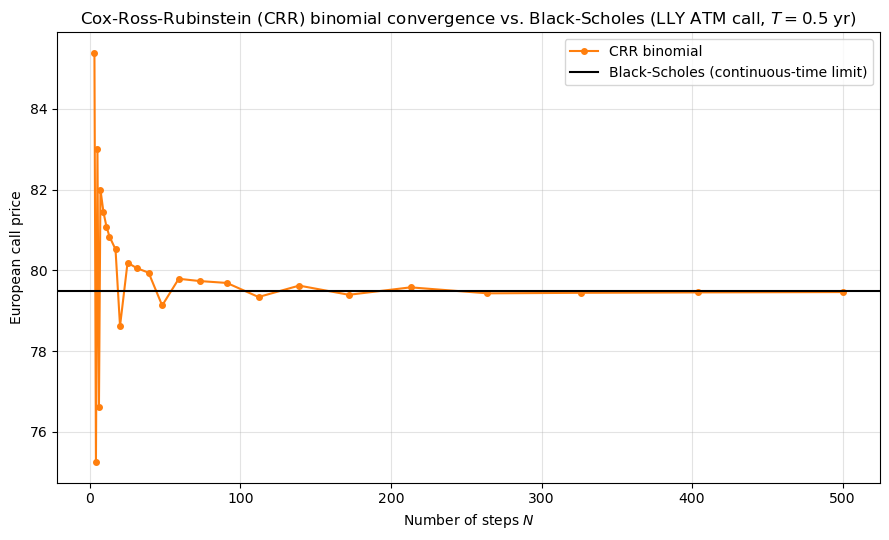

Final results:
  N = 3 binomial price:   $85.3888
  N = 500 binomial price: $79.4608
  Black-Scholes benchmark: $79.4962


In [ ]:
# Create a convergence plot

# Create a range of values for N within the range of 3 to 500
# Start at 3 because that's where manual calculation left off
# End at 500 (a relatively large number of steps)
N_binom = np.unique(
    np.clip(
        # Use logspace to have more samples at the low end of the range
        # where price is more sensitive
        # Take 25 samples to get a good range of values
        np.round(np.logspace(np.log10(3), np.log10(500), 25)).astype(int),
        3,
        500,
    )
)

# Run pricing function for each selected N
binom_prices = [crr_european_call(S0, K, T, r, sigma, int(n)) for n in N_binom]

# Plot results
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(N_binom, binom_prices, "o-", color="C1", markersize=4, label="CRR binomial")
ax.axhline(
    bs_benchmark_price,
    color="black",
    linestyle="-",
    linewidth=1.5,
    label="Black-Scholes (continuous-time limit)",
)
ax.set_xlabel("Number of steps $N$")
ax.set_ylabel("European call price")
ax.set_title(
    "Cox-Ross-Rubinstein (CRR) binomial convergence vs. Black-Scholes (LLY ATM call, $T=0.5$ yr)"
)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

print("Final results:")
print(f"  N = 3 binomial price:   ${crr_european_call(S0, K, T, r, sigma, 3):,.4f}")
print(f"  N = {N_binom[-1]} binomial price: ${binom_prices[-1]:,.4f}")
print(f"  Black-Scholes benchmark: ${bs_benchmark_price:,.4f}")

### (c) Comparing Methods

Compare the three methods in a summary table. For each method, report the option price and the wall-clock computation time (use Python’s time module or similar). Which method is fastest? Which is most flexible? When would you choose each one?

In [ ]:
import time
import pandas as pd

# Measure the computation time for each method.
# Report the option price and the wall-clock computation time.

# (1) Black–Scholes: Average evaluation time over many calls (200,000)
n_bs_reps = 200_000
t0 = time.perf_counter()
for _ in range(n_bs_reps):
    # Price the option (same function as before)
    price_bs = bs_call(S0, K, T, r, sigma)
elapsed_bs = time.perf_counter() - t0
time_bs_per_eval = elapsed_bs / n_bs_reps

# (2) Monte Carlo: N = 500,000 paths, n = 126 Euler–Maruyama steps (same as used for 2.2)
N_mc = 500_000
rng_table = np.random.default_rng(mc_seed)
t0 = time.perf_counter()
# Price the option (same function as before)
S_T_mc = simulate_terminal_prices_gbm(S0, r, sigma, T, mc_time_steps, N_mc, rng_table)
pay_mc = np.exp(-r * T) * np.maximum(S_T_mc - K, 0.0)
price_mc = float(np.mean(pay_mc))
elapsed_mc = time.perf_counter() - t0

# (3) CRR binomial: N = 500 steps (same range as used for the convergence plot in 2.3(b))
N_crr = 500
t0 = time.perf_counter()
# Price the option (same function as before)
price_crr = crr_european_call(S0, K, T, r, sigma, N_crr)
elapsed_crr = time.perf_counter() - t0

# Output time and price results
summary_23c = pd.DataFrame(
    {
        "Method": [
            "Black-Scholes",
            f"Monte Carlo (N = {N_mc:,} paths, {mc_time_steps} EM steps)",
            f"CRR binomial (N = {N_crr} steps)",
        ],
        "Price ($)": [price_bs, price_mc, price_crr],
        "Wall-clock time (s)": [time_bs_per_eval, elapsed_mc, elapsed_crr],
    }
)

# Print the summary table
print("Comparison of pricing methods:")
print(summary_23c.to_string(index=False))

Comparison of pricing methods:
                                       Method  Price ($)  Wall-clock time (s)
                                Black–Scholes  79.496175             0.000061
Monte Carlo (N = 500,000 paths, 126 EM steps)  79.452575             0.742742
                 CRR binomial (N = 500 steps)  79.460756             0.034182
